# Inversión Cinemática: Terremoto de Copiapó (06-06-2025)

Este notebook realiza la inversión utilizando los parámetros optimizados de axitra y el pre-procesador de datos con control de tiempo y padding.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
from obspy import UTCDateTime

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No root found.')

root = find_project_root(Path(os.getcwd()))
sys.path.append(str(root))
import kdellipspy as kde
print(f"Project root: {root}")

Project root: /home/alex/KDEllipsPy


In [2]:
input_ctl = root / 'inversions' / 'calama2020' / 'input.ctl'
cfg = kde.ConfigParser(filepath=str(input_ctl))
print(f"Evento: {cfg.source_position.event_name} | Estaciones originales: {len(cfg.stations.stations)}")
print("\n=== Configuración Completa ===")
print(f"Nombre del evento: {cfg.source_position.event_name}")
print(f"Tiempo de origen: {cfg.source_position.origin_time}")
print(f"Profundidad: {cfg.source_position.depth}")
print(f"Latitud: {cfg.source_position.latitude}")
print(f"Longitud: {cfg.source_position.longitude}")
print(f"\nDatos observados:")
print(f"  - Número de puntos (npts): {cfg.observed_data.npts}")
print(f"  - Delta (dt): {cfg.observed_data.delta}")
print(f"  - Duración: {cfg.observed_data.npts * cfg.observed_data.delta} s")
print(f"\nEstaciones ({len(cfg.stations.stations)}):")
for s in cfg.stations.stations:
    print(f"  - {s.name}: Lat {s.latitude}, Lon {s.longitude}, Alt {s.height}")

Evento: Calama 2020 Intraplate | Estaciones originales: 8

=== Configuración Completa ===
Nombre del evento: Calama 2020 Intraplate
Tiempo de origen: 2020-06-03T07:35:28.000Z
Profundidad: 123.4
Latitud: -23.247
Longitud: -68.53

Datos observados:
  - Número de puntos (npts): 512
  - Delta (dt): 0.25
  - Duración: 128.0 s

Estaciones (8):
  - A05C: Lat -27.3612, Lon -70.339, Alt 0.0
  - AC01: Lat -26.1479, Lon -70.5987, Alt 0.0
  - AC02: Lat -26.8355, Lon -69.1291, Alt 0.0
  - PB05: Lat -22.8528, Lon -70.2023, Alt 0.0
  - PB06: Lat -22.7058, Lon -69.5717, Alt 0.0
  - PB08: Lat -20.1411, Lon -69.1535, Alt 0.0
  - PB19: Lat -23.9048, Lon -69.29, Alt 0.0
  - T15A: Lat -20.2393, Lon -70.054, Alt 0.0


# 2. Visualizacion de parametros de inversion y de fuente


In [3]:
def mostrar_objeto(obj, nivel=0, max_nivel=2):
    pad = "  " * nivel

    if isinstance(obj, (str, int, float, bool, type(None), np.number)):
        print(f"{pad}{obj!r}")
        return

    if isinstance(obj, (list, tuple)):
        for i, item in enumerate(obj):
            print(f"{pad}[{i}]")
            mostrar_objeto(item, nivel + 1, max_nivel)
        return

    if hasattr(obj, "__dict__") and max_nivel >= 0:
        for k, v in vars(obj).items():
            if k.startswith("_"):
                continue
            if hasattr(v, "__dict__"):
                print(f"{pad}{k}:")
                mostrar_objeto(v, nivel + 1, max_nivel - 1)
            elif isinstance(v, (list, tuple)):
                print(f"{pad}{k}:")
                mostrar_objeto(v, nivel + 1, max_nivel - 1)
            else:
                print(f"{pad}{k}: {v!r}")
    else:
        print(f"{pad}{repr(obj)}")

mostrar_objeto(cfg)

filepath: '/home/alex/KDEllipsPy/inversions/calama2020/input.ctl'
observed_data:
  t1: 0.0
  t2: 128.0
  npts: 512
  delta: 0.25
  units: 2
source_position:
  event_name: 'Calama 2020 Intraplate'
  origin_time: '2020-06-03T07:35:28.000Z'
  latitude: -23.247
  longitude: -68.53
  depth: 123.4
  strike: 333.0
  dip: 60.0
  rake: -91.0
fault_plane:
  lx: 32000.0
  ly: 32000.0
  hx: 16000.0
  hy: 16000.0
  nx: 30
  ny: 30
ellipse:
  num_ellipses: 1
  initial_slip: 0
  slip_shape: 1
  freq1: 0.02
  freq2: 0.1
  t0: 3.0
inversion_params:
  parameters:
    [0]
      name: 'Length of axis 1                 (km)'
      min_val: 4.0
      max_val: 13.0
      flag: 1
    [1]
      name: 'Length of axis 2                 (km)'
      min_val: 4.0
      max_val: 13.0
      flag: 1
    [2]
      name: 'Rotation angle                 (x pi)'
      min_val: 0.0
      max_val: 2.0
      flag: 1
    [3]
      name: 'Position of the center np'
      min_val: 0.0
      max_val: 1.0
      flag: 1
    [4]
  

## 4. Inversión Neighbourhood Algorithm (NA)

In [3]:
output_dir = root / 'inversions' / 'calama2020' / 'DATA'
observed_waveforms, time_array = kde.load_and_filter_observed_data(
    config=cfg,
    data_dir=str(output_dir),
    prefer_raw=False,
)

azi_times_array = kde.build_azi_times_array(config=cfg)

inversion = kde.NAInversionModel(
    config=cfg,
    observed_waveforms=observed_waveforms,
    time_array=time_array,
    azi_times_array=azi_times_array,
    axitra_aw=0.5,
    axitra_ikmax=100000
)

result = inversion.run_na_search()

[NA] Adjusting n_samples_iteration from 30 to 32 to satisfy neighpy constraint (must be a multiple of n_cells_resample=4).
[NA] Starting search: ni=200, ns=32, n=5, nr=4 -> expected evaluations=360
NAI - Initial Random Search
[NA] iter=00000 eval=00001 misfit=2.880850e+00 best=2.880850e+00 mt_mode=no_mt dmax_req=3.520590e+00 dmax_eff=3.520590e+00 M0_target=n/a M0_L1=6.757437e+19
[NA] iter=00000 eval=00002 misfit=3.482500e+00 best=2.880850e+00 mt_mode=no_mt dmax_req=2.932563e+00 dmax_eff=2.932563e+00 M0_target=n/a M0_L1=2.351042e+19
[NA] iter=00000 eval=00003 misfit=2.005172e+00 best=2.005172e+00 mt_mode=no_mt dmax_req=4.421878e+00 dmax_eff=4.421878e+00 M0_target=n/a M0_L1=5.798573e+19
[NA] iter=00000 eval=00004 misfit=5.274373e+00 best=2.005172e+00 mt_mode=no_mt dmax_req=5.468510e+00 dmax_eff=5.468510e+00 M0_target=n/a M0_L1=3.604626e+19
[NA] iter=00000 eval=00005 misfit=2.021558e+00 best=2.005172e+00 mt_mode=no_mt dmax_req=3.207872e+00 dmax_eff=3.207872e+00 M0_target=n/a M0_L1=2.43329

NAI - Optimisation Loop:   0%|          | 0/5 [00:00<?, ?it/s]

[NA] iter=00001 eval=00201 misfit=1.067753e+00 best=7.773862e-01 mt_mode=no_mt dmax_req=2.201975e+00 dmax_eff=2.201975e+00 M0_target=n/a M0_L1=1.304250e+19
[NA] iter=00001 eval=00202 misfit=8.618116e-01 best=7.773862e-01 mt_mode=no_mt dmax_req=1.805022e+00 dmax_eff=1.805022e+00 M0_target=n/a M0_L1=1.115284e+19
[NA] iter=00001 eval=00203 misfit=8.912221e-01 best=7.773862e-01 mt_mode=no_mt dmax_req=1.935131e+00 dmax_eff=1.935131e+00 M0_target=n/a M0_L1=9.880745e+18
[NA] iter=00001 eval=00204 misfit=8.370013e-01 best=7.773862e-01 mt_mode=no_mt dmax_req=2.323019e+00 dmax_eff=2.323019e+00 M0_target=n/a M0_L1=1.373250e+19
[NA] iter=00001 eval=00205 misfit=1.216688e+00 best=7.773862e-01 mt_mode=no_mt dmax_req=2.515541e+00 dmax_eff=2.515541e+00 M0_target=n/a M0_L1=1.348291e+19
[NA] iter=00001 eval=00206 misfit=8.584526e-01 best=7.773862e-01 mt_mode=no_mt dmax_req=1.753220e+00 dmax_eff=1.753220e+00 M0_target=n/a M0_L1=1.017103e+19
[NA] iter=00001 eval=00207 misfit=1.166134e+00 best=7.773862e-01

NAI - Optimisation Loop:  20%|██        | 1/5 [01:20<05:21, 80.28s/it]

[NA] iter=00002 eval=00233 misfit=8.305758e-01 best=7.773862e-01 mt_mode=no_mt dmax_req=2.032729e+00 dmax_eff=2.032729e+00 M0_target=n/a M0_L1=1.245053e+19
[NA] iter=00002 eval=00234 misfit=7.763529e-01 best=7.763529e-01 mt_mode=no_mt dmax_req=1.741958e+00 dmax_eff=1.741958e+00 M0_target=n/a M0_L1=1.087847e+19
[NA] iter=00002 eval=00235 misfit=7.762222e-01 best=7.762222e-01 mt_mode=no_mt dmax_req=1.837263e+00 dmax_eff=1.837263e+00 M0_target=n/a M0_L1=1.053064e+19
[NA] iter=00002 eval=00236 misfit=1.009888e+00 best=7.762222e-01 mt_mode=no_mt dmax_req=2.121395e+00 dmax_eff=2.121395e+00 M0_target=n/a M0_L1=1.310148e+19
[NA] iter=00002 eval=00237 misfit=1.014227e+00 best=7.762222e-01 mt_mode=no_mt dmax_req=2.262420e+00 dmax_eff=2.262420e+00 M0_target=n/a M0_L1=1.323354e+19
[NA] iter=00002 eval=00238 misfit=1.011925e+00 best=7.762222e-01 mt_mode=no_mt dmax_req=1.704012e+00 dmax_eff=1.704012e+00 M0_target=n/a M0_L1=1.035364e+19
[NA] iter=00002 eval=00239 misfit=9.013649e-01 best=7.762222e-01

...

NAI - Optimisation Loop:  60%|██████    | 3/5 [03:38<02:20, 70.10s/it]

[NA] iter=00004 eval=00297 misfit=7.591697e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.669130e+00 dmax_eff=1.669130e+00 M0_target=n/a M0_L1=1.085872e+19
[NA] iter=00004 eval=00298 misfit=7.674101e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.574744e+00 dmax_eff=1.574744e+00 M0_target=n/a M0_L1=1.028412e+19
[NA] iter=00004 eval=00299 misfit=7.776740e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.605680e+00 dmax_eff=1.605680e+00 M0_target=n/a M0_L1=1.028905e+19
[NA] iter=00004 eval=00300 misfit=9.286876e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.697911e+00 dmax_eff=1.697911e+00 M0_target=n/a M0_L1=1.112267e+19
[NA] iter=00004 eval=00301 misfit=7.806342e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.743688e+00 dmax_eff=1.743688e+00 M0_target=n/a M0_L1=1.120042e+19
[NA] iter=00004 eval=00302 misfit=9.217242e-01 best=7.591697e-01 mt_mode=no_mt dmax_req=1.562426e+00 dmax_eff=1.562426e+00 M0_target=n/a M0_L1=1.020645e+19
[NA] iter=00004 eval=00303 misfit=7.620000e-01 best=7.591697e-01

NAI - Optimisation Loop:  80%|████████  | 4/5 [04:36<01:05, 65.46s/it]

[NA] iter=00005 eval=00329 misfit=7.699119e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.912069e+00 dmax_eff=1.912069e+00 M0_target=n/a M0_L1=1.192711e+19
[NA] iter=00005 eval=00330 misfit=7.596844e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.858780e+00 dmax_eff=1.858780e+00 M0_target=n/a M0_L1=1.181171e+19
[NA] iter=00005 eval=00331 misfit=7.630152e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.876246e+00 dmax_eff=1.876246e+00 M0_target=n/a M0_L1=1.143053e+19
[NA] iter=00005 eval=00332 misfit=7.544323e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.928319e+00 dmax_eff=1.928319e+00 M0_target=n/a M0_L1=1.216998e+19
[NA] iter=00005 eval=00333 misfit=8.221693e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.954164e+00 dmax_eff=1.954164e+00 M0_target=n/a M0_L1=1.198956e+19
[NA] iter=00005 eval=00334 misfit=7.599079e-01 best=7.497036e-01 mt_mode=no_mt dmax_req=1.851826e+00 dmax_eff=1.851826e+00 M0_target=n/a M0_L1=1.137008e+19
[NA] iter=00005 eval=00335 misfit=7.827872e-01 best=7.497036e-01

NAI - Optimisation Loop: 100%|██████████| 5/5 [05:37<00:00, 67.47s/it]


PLOT RESULTS

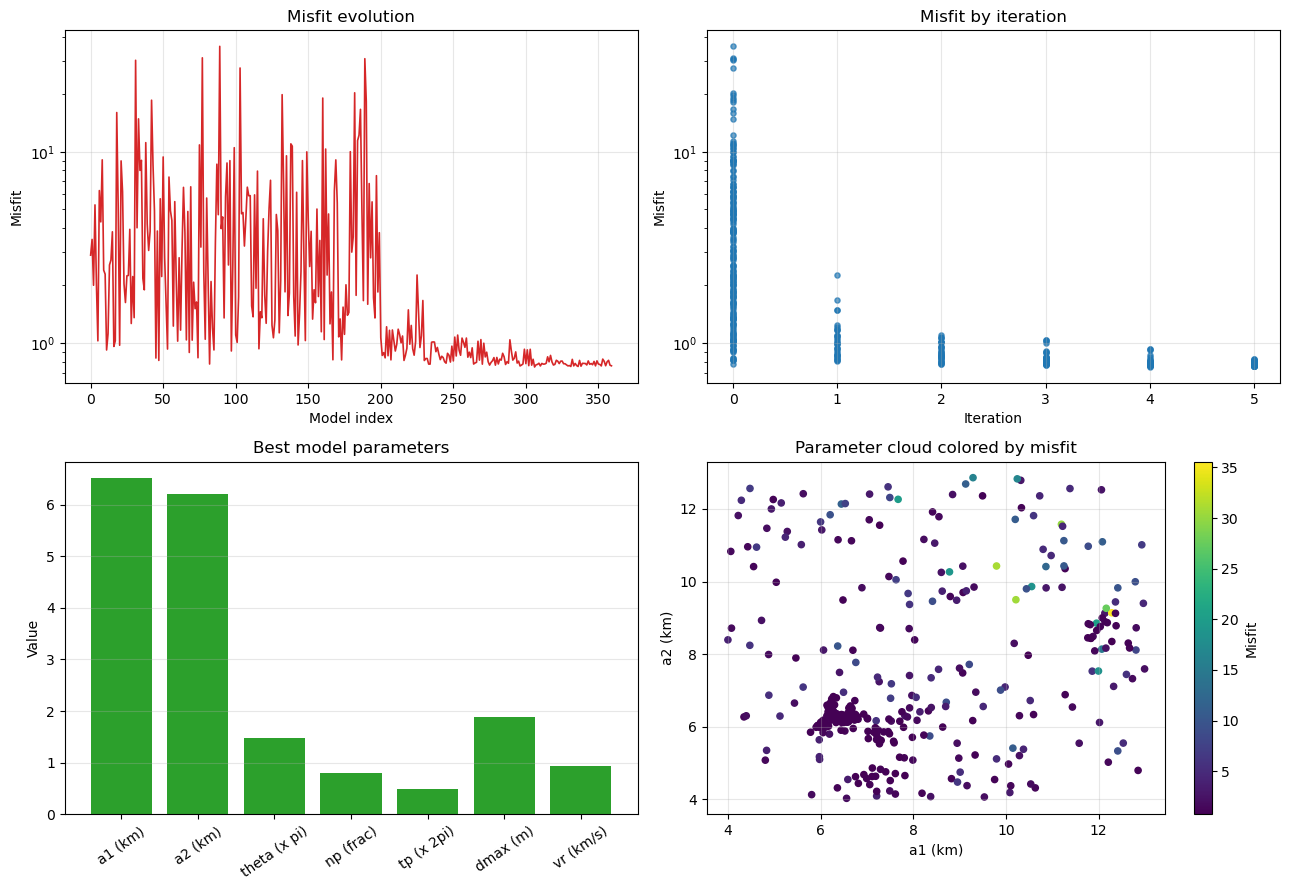

In [9]:
import os
os.makedirs('./Figures', exist_ok=True)
fig, ax = result.plot(show=True, save_path='./Figures/na_results.png')
